# Exploration des Données (EDA) - Dataset Cassava

**Objectif :** Analyser en profondeur le dataset de feuilles de manioc pour comprendre :
- La distribution des classes
- La qualité et les caractéristiques des images
- Les patterns visuels de chaque maladie
- Les défis potentiels pour le fine-tuning

**Dataset :** Kaggle Cassava Leaf Disease Classification
- 21,397 images d'entraînement
- 5 classes : 4 maladies + healthy
- Format : JPG, dimensions variables

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration des chemins
DATA_DIR = Path("../data/raw")
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_IMAGES_DIR = DATA_DIR / "train_images"
LABEL_MAP_FILE = DATA_DIR / "label_num_to_disease_map.json"
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("EXPLORATION DES DONNÉES - CASSAVA LEAF DISEASE DATASET")
print("=" * 70)
print(f"Répertoire des données: {DATA_DIR}")
print(f"Fichier CSV: {TRAIN_CSV}")
print(f"Images: {TRAIN_IMAGES_DIR}")
print("=" * 70)

EXPLORATION DES DONNÉES - CASSAVA LEAF DISEASE DATASET
Répertoire des données: ../data/raw
Fichier CSV: ../data/raw/train.csv
Images: ../data/raw/train_images


## 2. Chargement des données

In [2]:
# Charger le mapping des labels
with open(LABEL_MAP_FILE, 'r') as f:
    label_map = json.load(f)

print("Mapping des labels:")
print("-" * 70)
for label, disease in sorted(label_map.items(), key=lambda x: int(x[0])):
    print(f"  {label}: {disease}")

# Créer un mapping inverse pour faciliter l'usage
label_to_disease = {int(k): v for k, v in label_map.items()}

# Charger le CSV
df = pd.read_csv(TRAIN_CSV)
print(f"\n✓ Dataset chargé: {len(df)} images")
print(f"✓ Colonnes: {list(df.columns)}")

# Ajouter la colonne disease_name
df['disease_name'] = df['label'].map(label_to_disease)

# Aperçu des données
print("\nAperçu du dataset:")
df.head(10)

Mapping des labels:
----------------------------------------------------------------------
  0: Cassava Bacterial Blight (CBB)
  1: Cassava Brown Streak Disease (CBSD)
  2: Cassava Green Mottle (CGM)
  3: Cassava Mosaic Disease (CMD)
  4: Healthy

✓ Dataset chargé: 21397 images
✓ Colonnes: ['image_id', 'label']

Aperçu du dataset:


,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
5,1000837476.jpg,3,Cassava Mosaic Disease (CMD)
6,1000910826.jpg,2,Cassava Green Mottle (CGM)
7,1001320321.jpg,0,Cassava Bacterial Blight (CBB)
8,1001723730.jpg,4,Healthy
9,1001742395.jpg,3,Cassava Mosaic Disease (CMD)


## 3. Distribution des classes

Analysons la répartition des images entre les différentes classes.

Distribution des classes:
  Label 0 - Cassava Bacterial Blight (CBB)          :  1087 images ( 5.08%)
  Label 1 - Cassava Brown Streak Disease (CBSD)     :  2189 images (10.23%)
  Label 2 - Cassava Green Mottle (CGM)              :  2386 images (11.15%)
  Label 3 - Cassava Mosaic Disease (CMD)            : 13158 images (61.49%)
  Label 4 - Healthy                                 :  2577 images (12.04%)
  Total: 21397 images


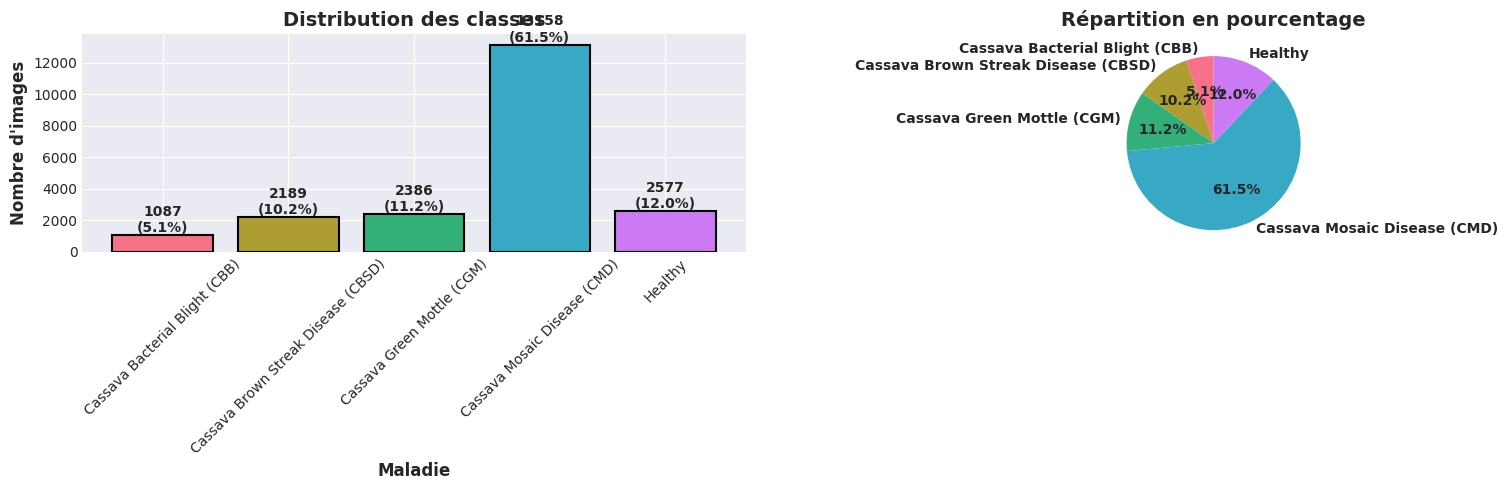


✓ Graphique sauvegardé: outputs/class_distribution.png


In [3]:
# Compter les images par classe
class_counts = df['label'].value_counts().sort_index()

print("Distribution des classes:")
print("=" * 70)
total = len(df)
for label in sorted(class_counts.index):
    count = class_counts[label]
    disease = label_to_disease[label]
    percentage = (count / total) * 100
    print(f"  Label {label} - {disease:40s}: {count:5d} images ({percentage:5.2f}%)")
print("=" * 70)
print(f"  Total: {total} images")

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique en barres
ax1 = axes[0]
disease_names = [label_to_disease[i] for i in sorted(class_counts.index)]
colors = sns.color_palette("husl", len(disease_names))
bars = ax1.bar(disease_names, class_counts.sort_index(), color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Maladie', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nombre d\'images', fontsize=12, fontweight='bold')
ax1.set_title('Distribution des classes', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, count in zip(bars, class_counts.sort_index()):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Graphique en camembert
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    class_counts.sort_index(), 
    labels=disease_names,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
ax2.set_title('Répartition en pourcentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Graphique sauvegardé: outputs/class_distribution.png")

### Analyse du déséquilibre des classes

In [4]:
# Calculer le ratio de déséquilibre
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class

print("Analyse du déséquilibre des classes:")
print("=" * 70)
print(f"  Classe majoritaire: {label_to_disease[class_counts.idxmax()]}")
print(f"    Nombre d'images: {max_class}")
print(f"\n  Classe minoritaire: {label_to_disease[class_counts.idxmin()]}")
print(f"    Nombre d'images: {min_class}")
print(f"\n  Ratio de déséquilibre: {imbalance_ratio:.2f}:1")
print("=" * 70)

if imbalance_ratio > 3:
    print("\n⚠️  DÉSÉQUILIBRE SIGNIFICATIF DÉTECTÉ!")
    print("   Stratégies recommandées:")
    print("   - Utiliser des poids de classe (class_weight) pendant l'entraînement")
    print("   - Appliquer de l'augmentation de données sur les classes minoritaires")
    print("   - Utiliser une loss fonction adaptée (Focal Loss, etc.)")
elif imbalance_ratio > 2:
    print("\n⚠️  Déséquilibre modéré détecté")
    print("   Recommandation: Utiliser des poids de classe pendant l'entraînement")
else:
    print("\n✓ Distribution relativement équilibrée")

Analyse du déséquilibre des classes:
  Classe majoritaire: Cassava Mosaic Disease (CMD)
    Nombre d'images: 13158

  Classe minoritaire: Cassava Bacterial Blight (CBB)
    Nombre d'images: 1087

  Ratio de déséquilibre: 12.10:1

⚠️  DÉSÉQUILIBRE SIGNIFICATIF DÉTECTÉ!
   Stratégies recommandées:
   - Utiliser des poids de classe (class_weight) pendant l'entraînement
   - Appliquer de l'augmentation de données sur les classes minoritaires
   - Utiliser une loss fonction adaptée (Focal Loss, etc.)


## 4. Analyse des caractéristiques des images

Examinons les propriétés techniques des images (dimensions, taille, format).

In [5]:
# Fonction pour extraire les métadonnées d'une image
def get_image_metadata(image_path):
    """Extrait les métadonnées d'une image"""
    try:
        img = Image.open(image_path)
        return {
            'width': img.width,
            'height': img.height,
            'aspect_ratio': img.width / img.height,
            'size_bytes': image_path.stat().st_size,
            'format': img.format,
            'mode': img.mode
        }
    except Exception as e:
        return None

# Échantillonner 1000 images pour l'analyse (pour accélérer)
print("Analyse des métadonnées des images...")
print("(Échantillon de 1000 images pour accélérer l'analyse)\n")

sample_size = min(1000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

metadata_list = []
for image_id in sample_df['image_id']:
    image_path = TRAIN_IMAGES_DIR / image_id
    metadata = get_image_metadata(image_path)
    if metadata:
        metadata_list.append(metadata)

# Créer un DataFrame avec les métadonnées
meta_df = pd.DataFrame(metadata_list)

print("Statistiques des images:")
print("=" * 70)
print(f"\nDimensions (pixels):")
print(f"  Largeur  - Min: {meta_df['width'].min():4d} | Max: {meta_df['width'].max():4d} | Moyenne: {meta_df['width'].mean():.0f}")
print(f"  Hauteur  - Min: {meta_df['height'].min():4d} | Max: {meta_df['height'].max():4d} | Moyenne: {meta_df['height'].mean():.0f}")
print(f"\nRatio d'aspect:")
print(f"  Min: {meta_df['aspect_ratio'].min():.3f} | Max: {meta_df['aspect_ratio'].max():.3f} | Moyenne: {meta_df['aspect_ratio'].mean():.3f}")
print(f"\nTaille des fichiers:")
print(f"  Min: {meta_df['size_bytes'].min()/1024:.1f} KB | Max: {meta_df['size_bytes'].max()/1024:.1f} KB | Moyenne: {meta_df['size_bytes'].mean()/1024:.1f} KB")
print(f"\nFormat: {meta_df['format'].unique()}")
print(f"Mode: {meta_df['mode'].unique()}")
print("=" * 70)

Analyse des métadonnées des images...
(Échantillon de 1000 images pour accélérer l'analyse)

Statistiques des images:

Dimensions (pixels):
  Largeur  - Min:  800 | Max:  800 | Moyenne: 800
  Hauteur  - Min:  600 | Max:  600 | Moyenne: 600

Ratio d'aspect:
  Min: 1.333 | Max: 1.333 | Moyenne: 1.333

Taille des fichiers:
  Min: 40.5 KB | Max: 190.8 KB | Moyenne: 116.7 KB

Format: ['JPEG']
Mode: ['RGB']


### Visualisation des distributions des dimensions

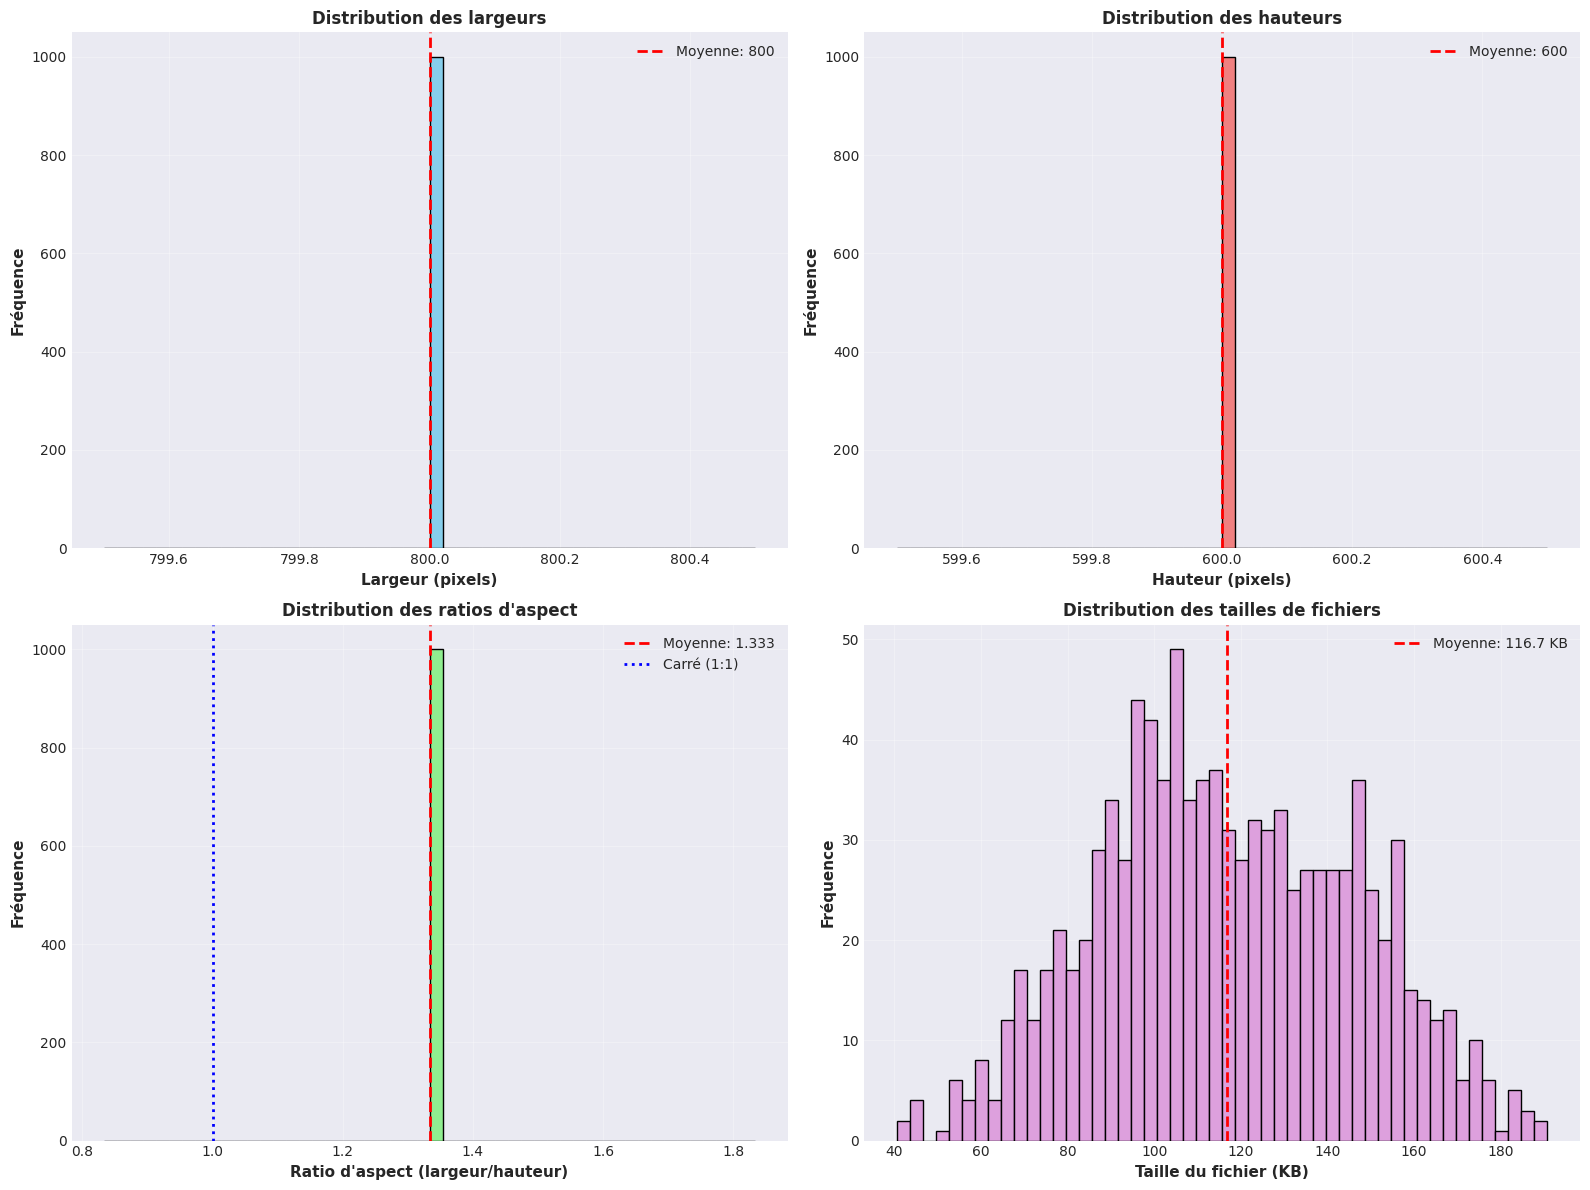

✓ Graphique sauvegardé: outputs/image_dimensions_analysis.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution des largeurs
axes[0, 0].hist(meta_df['width'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(meta_df['width'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {meta_df["width"].mean():.0f}')
axes[0, 0].set_xlabel('Largeur (pixels)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution des largeurs', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution des hauteurs
axes[0, 1].hist(meta_df['height'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].axvline(meta_df['height'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {meta_df["height"].mean():.0f}')
axes[0, 1].set_xlabel('Hauteur (pixels)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution des hauteurs', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution des ratios d'aspect
axes[1, 0].hist(meta_df['aspect_ratio'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].axvline(meta_df['aspect_ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {meta_df["aspect_ratio"].mean():.3f}')
axes[1, 0].axvline(1.0, color='blue', linestyle=':', linewidth=2, label='Carré (1:1)')
axes[1, 0].set_xlabel('Ratio d\'aspect (largeur/hauteur)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Distribution des ratios d\'aspect', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Distribution des tailles de fichiers
axes[1, 1].hist(meta_df['size_bytes']/1024, bins=50, color='plum', edgecolor='black')
axes[1, 1].axvline(meta_df['size_bytes'].mean()/1024, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {meta_df["size_bytes"].mean()/1024:.1f} KB')
axes[1, 1].set_xlabel('Taille du fichier (KB)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Distribution des tailles de fichiers', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_dimensions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: outputs/image_dimensions_analysis.png")

## 5. Visualisation d'échantillons par classe

Affichons plusieurs exemples de chaque classe pour identifier les patterns visuels.

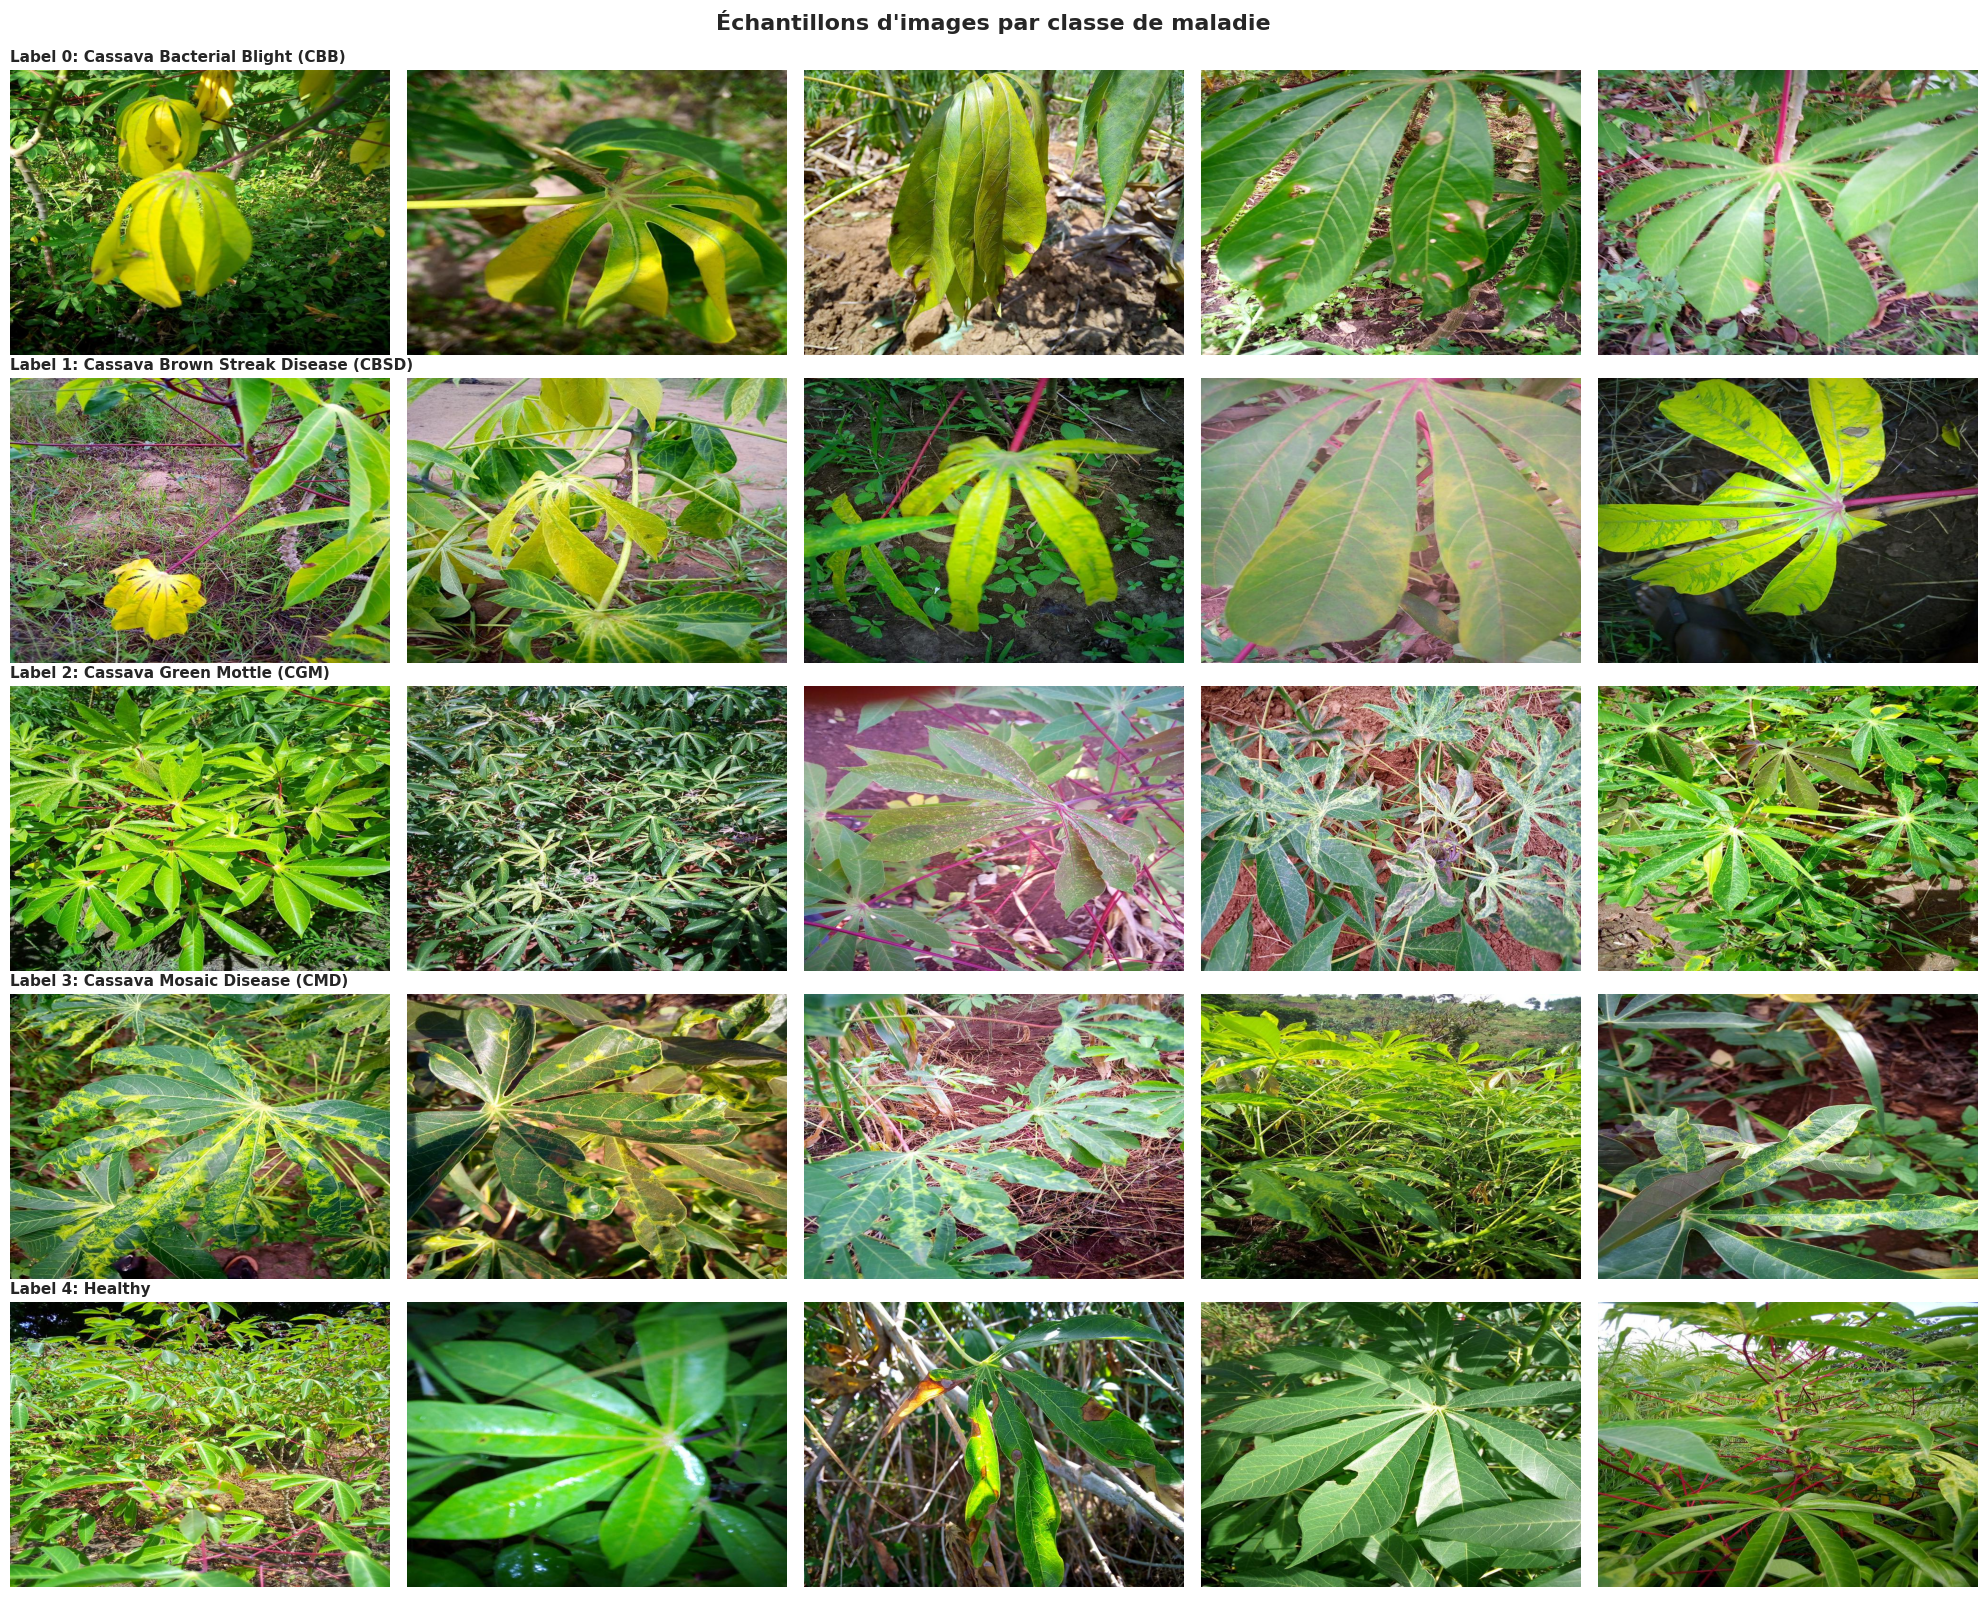

✓ Graphique sauvegardé: outputs/samples_by_class.png


In [7]:
# Sélectionner 5 images aléatoires par classe
samples_per_class = 5
num_classes = len(label_to_disease)

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(20, 16))

for class_idx, label in enumerate(sorted(label_to_disease.keys())):
    disease_name = label_to_disease[label]
    
    # Sélectionner des images de cette classe
    class_images = df[df['label'] == label].sample(n=samples_per_class, random_state=42)
    
    for img_idx, (_, row) in enumerate(class_images.iterrows()):
        image_path = TRAIN_IMAGES_DIR / row['image_id']
        img = Image.open(image_path)
        
        ax = axes[class_idx, img_idx]
        ax.imshow(img)
        ax.axis('off')
        
        # Titre uniquement pour la première colonne
        if img_idx == 0:
            ax.set_title(f"Label {label}: {disease_name}", 
                        fontsize=11, fontweight='bold', loc='left')

plt.suptitle('Échantillons d\'images par classe de maladie', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: outputs/samples_by_class.png")

## 6. Analyse des caractéristiques visuelles par classe

Analysons les propriétés visuelles spécifiques à chaque classe.

In [8]:
# Fonction pour calculer les statistiques de couleur d'une image
def get_color_stats(image_path):
    """Calcule les statistiques de couleur (RGB) d'une image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img)
        
        return {
            'mean_r': img_array[:, :, 0].mean(),
            'mean_g': img_array[:, :, 1].mean(),
            'mean_b': img_array[:, :, 2].mean(),
            'std_r': img_array[:, :, 0].std(),
            'std_g': img_array[:, :, 1].std(),
            'std_b': img_array[:, :, 2].std(),
            'brightness': img_array.mean()
        }
    except Exception as e:
        return None

print("Analyse des caractéristiques de couleur par classe...")
print("(Échantillon de 100 images par classe)\n")

color_stats_by_class = {}

for label in sorted(label_to_disease.keys()):
    disease_name = label_to_disease[label]
    class_images = df[df['label'] == label].sample(n=min(100, len(df[df['label'] == label])), random_state=42)
    
    stats_list = []
    for image_id in class_images['image_id']:
        image_path = TRAIN_IMAGES_DIR / image_id
        stats = get_color_stats(image_path)
        if stats:
            stats_list.append(stats)
    
    color_stats_by_class[label] = pd.DataFrame(stats_list)
    
print("✓ Analyse terminée")

Analyse des caractéristiques de couleur par classe...
(Échantillon de 100 images par classe)

✓ Analyse terminée


### Visualisation des statistiques de couleur par classe

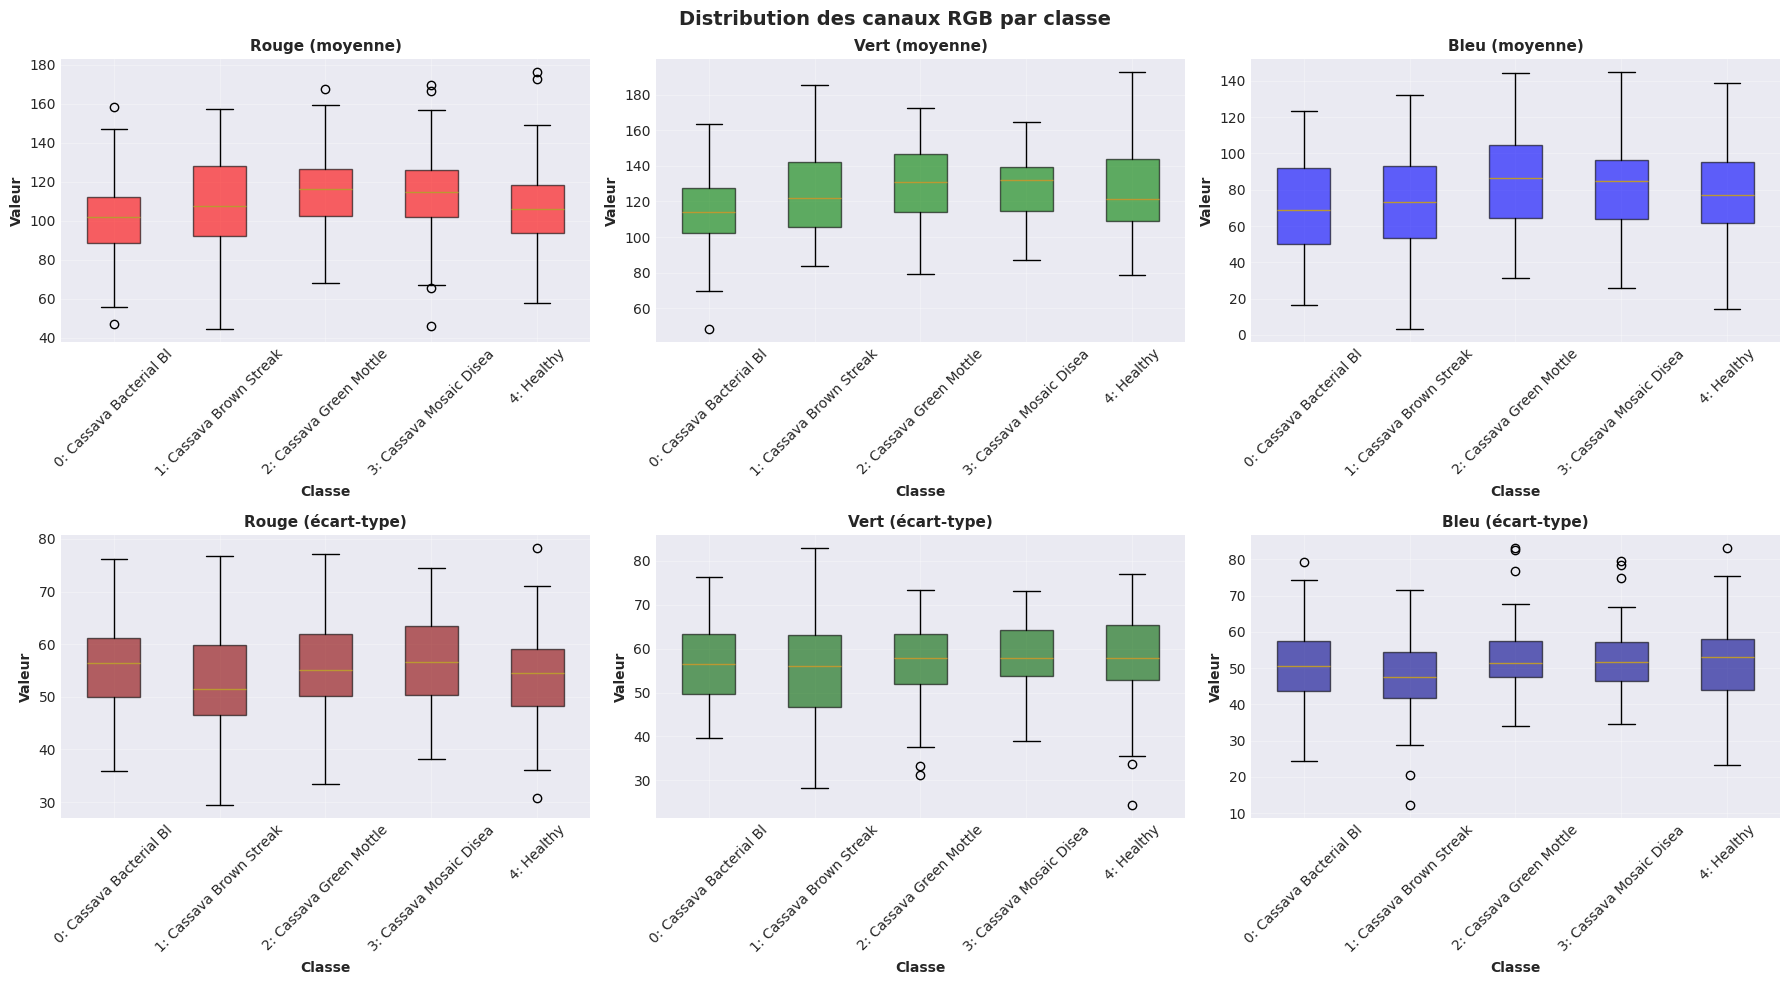

✓ Graphique sauvegardé: outputs/color_stats_by_class.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

channels = ['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']
channel_names = ['Rouge (moyenne)', 'Vert (moyenne)', 'Bleu (moyenne)', 
                 'Rouge (écart-type)', 'Vert (écart-type)', 'Bleu (écart-type)']
colors_plot = ['red', 'green', 'blue', 'darkred', 'darkgreen', 'darkblue']

for idx, (channel, channel_name, color) in enumerate(zip(channels, channel_names, colors_plot)):
    ax = axes[idx]
    
    data_to_plot = []
    labels_plot = []
    
    for label in sorted(label_to_disease.keys()):
        disease_name = label_to_disease[label]
        data_to_plot.append(color_stats_by_class[label][channel])
        labels_plot.append(f"{label}: {disease_name[:20]}")
    
    bp = ax.boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
    
    # Colorer les boîtes
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_xlabel('Classe', fontsize=10, fontweight='bold')
    ax.set_ylabel('Valeur', fontsize=10, fontweight='bold')
    ax.set_title(channel_name, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution des canaux RGB par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'color_stats_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: outputs/color_stats_by_class.png")

### Analyse de la luminosité par classe

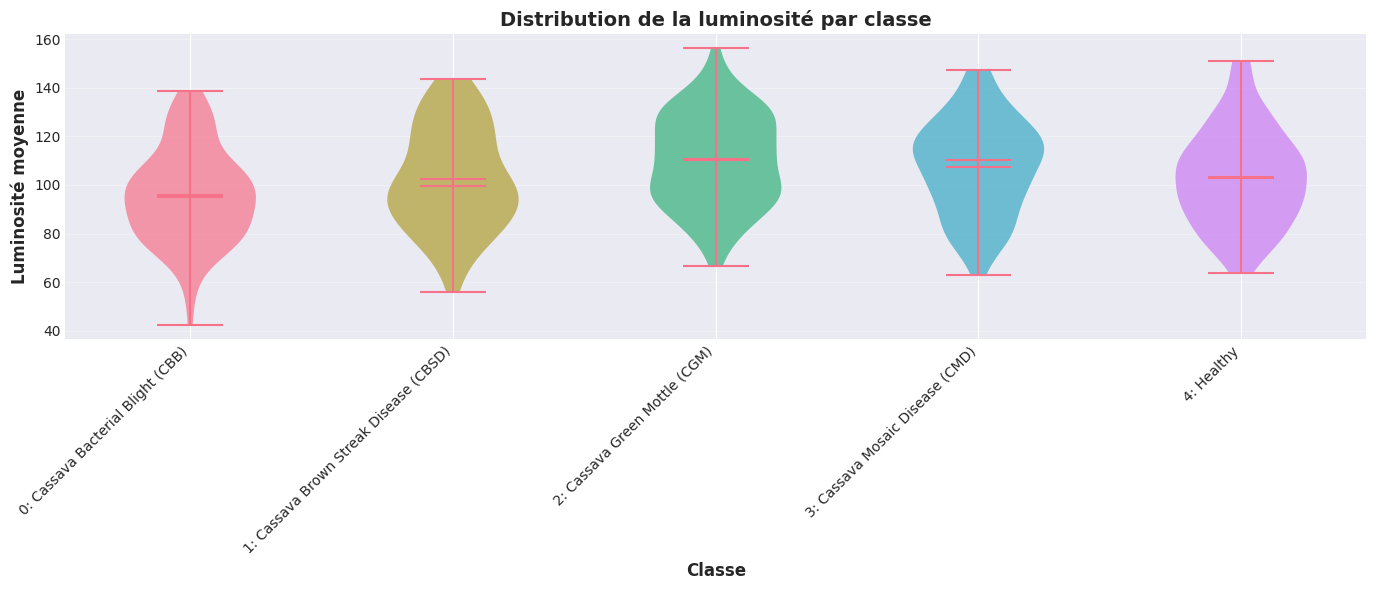

✓ Graphique sauvegardé: outputs/brightness_by_class.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

brightness_data = []
labels_plot = []

for label in sorted(label_to_disease.keys()):
    disease_name = label_to_disease[label]
    brightness_data.append(color_stats_by_class[label]['brightness'])
    labels_plot.append(f"{label}: {disease_name}")

violin_parts = ax.violinplot(brightness_data, positions=range(len(brightness_data)), 
                             showmeans=True, showmedians=True)

# Colorer les violons
colors = sns.color_palette("husl", len(brightness_data))
for pc, color in zip(violin_parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot, rotation=45, ha='right')
ax.set_xlabel('Classe', fontsize=12, fontweight='bold')
ax.set_ylabel('Luminosité moyenne', fontsize=12, fontweight='bold')
ax.set_title('Distribution de la luminosité par classe', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'brightness_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: outputs/brightness_by_class.png")

## 7. Observations et caractéristiques visuelles par maladie

In [11]:
print("="*70)
print("CARACTÉRISTIQUES VISUELLES DES MALADIES DU MANIOC")
print("="*70)

observations = {
    0: {
        'name': 'Cassava Bacterial Blight (CBB)',
        'symptoms': [
            '• Taches angulaires brun foncé sur les feuilles',
            '• Flétrissement et dessèchement des feuilles',
            '• Exsudat bactérien visible (gommose)',
            '• Nécrose progressive des tissus'
        ],
        'visual': 'Feuilles avec zones brunâtres et flétrissement caractéristique'
    },
    1: {
        'name': 'Cassava Brown Streak Disease (CBSD)',
        'symptoms': [
            '• Stries brunes ou pourpres sur les pétioles et tiges',
            '• Chlorose (jaunissement) des feuilles',
            '• Nécrose des nervures foliaires',
            '• Déformation des feuilles jeunes'
        ],
        'visual': 'Stries caractéristiques et décoloration progressive'
    },
    2: {
        'name': 'Cassava Green Mottle (CGM)',
        'symptoms': [
            '• Marbrures vertes inégales sur le limbe',
            '• Zones vert pâle alternant avec du vert foncé',
            '• Feuilles généralement saines sans nécrose',
            '• Peut affecter la croissance générale'
        ],
        'visual': 'Motif de mosaïque vert clair/foncé sans brunissement'
    },
    3: {
        'name': 'Cassava Mosaic Disease (CMD)',
        'symptoms': [
            '• Mosaïque jaune-vert caractéristique',
            '• Déformation et réduction de taille des feuilles',
            '• Chlorose internervaire marquée',
            '• Nanisme de la plante dans les cas sévères'
        ],
        'visual': 'Mosaïque prononcée jaune/vert avec déformation foliaire'
    },
    4: {
        'name': 'Healthy',
        'symptoms': [
            '• Feuilles vertes uniformes',
            '• Absence de taches, décolorations ou nécroses',
            '• Nervures claires et bien définies',
            '• Croissance normale'
        ],
        'visual': 'Vert uniforme, feuilles vigoureuses sans anomalies'
    }
}

for label, info in observations.items():
    print(f"\n{label}. {info['name']}")
    print("-" * 70)
    print("Symptômes visibles:")
    for symptom in info['symptoms']:
        print(f"  {symptom}")
    print(f"\nCaractéristique principale: {info['visual']}")

print("\n" + "="*70)

CARACTÉRISTIQUES VISUELLES DES MALADIES DU MANIOC

0. Cassava Bacterial Blight (CBB)
----------------------------------------------------------------------
Symptômes visibles:
  • Taches angulaires brun foncé sur les feuilles
  • Flétrissement et dessèchement des feuilles
  • Exsudat bactérien visible (gommose)
  • Nécrose progressive des tissus

Caractéristique principale: Feuilles avec zones brunâtres et flétrissement caractéristique

1. Cassava Brown Streak Disease (CBSD)
----------------------------------------------------------------------
Symptômes visibles:
  • Stries brunes ou pourpres sur les pétioles et tiges
  • Chlorose (jaunissement) des feuilles
  • Nécrose des nervures foliaires
  • Déformation des feuilles jeunes

Caractéristique principale: Stries caractéristiques et décoloration progressive

2. Cassava Green Mottle (CGM)
----------------------------------------------------------------------
Symptômes visibles:
  • Marbrures vertes inégales sur le limbe
  • Zones vert 

## 8. Recommandations pour le prétraitement et le fine-tuning

In [12]:
print("="*70)
print("RECOMMANDATIONS BASÉES SUR L'EDA")
print("="*70)

print("\n1. GESTION DU DÉSÉQUILIBRE DES CLASSES")
print("-" * 70)
if imbalance_ratio > 3:
    print("  ⚠️  Déséquilibre fort détecté (ratio {:.2f}:1)".format(imbalance_ratio))
    print("  Actions recommandées:")
    print("    • Utiliser des poids de classe inversement proportionnels")
    print("    • Appliquer de l'augmentation de données ciblée sur classes minoritaires")
    print("    • Envisager le sur-échantillonnage (oversampling) des classes rares")
    print("    • Utiliser Focal Loss pour se concentrer sur les exemples difficiles")
else:
    print("  ✓ Déséquilibre modéré - poids de classe suffisants")

print("\n2. PRÉTRAITEMENT DES IMAGES")
print("-" * 70)
print("  Dimensions variables détectées:")
print(f"    • Largeur:  {meta_df['width'].min()} - {meta_df['width'].max()} pixels")
print(f"    • Hauteur:  {meta_df['height'].min()} - {meta_df['height'].max()} pixels")
print("\n  Actions recommandées:")
print("    • Segmentation des feuilles (GroundingDINO + SAM-3)")
print("    • Redimensionnement uniforme (ex: 448x448 pour Qwen2.5-VL)")
print("    • Normalisation selon les stats ImageNet ou dataset-specific")
print("    • Suppression des arrière-plans complexes")

print("\n3. AUGMENTATION DE DONNÉES")
print("-" * 70)
print("  Transformations recommandées:")
print("    • Rotation: ±45° (feuilles peuvent être orientées différemment)")
print("    • Flip horizontal/vertical (symétrie naturelle)")
print("    • Ajustement de luminosité: ±20% (conditions d'éclairage variables)")
print("    • Ajustement de contraste: ±15% (améliore la détection des symptômes)")
print("    • Zoom: 0.8-1.2x (distances de capture variables)")
print("    • ⚠️  Éviter les transformations qui altèrent les symptômes de maladies")

print("\n4. STRATÉGIE DE FINE-TUNING")
print("-" * 70)
print("  Configuration LoRA recommandée:")
print("    • Rank (r): 16 (bon compromis performance/coût)")
print("    • Alpha (α): 32 (scaling factor pour stabilité)")
print("    • Dropout: 0.05 (régularisation légère)")
print("    • Target modules: q_proj, k_proj, v_proj, o_proj")
print("\n  Hyperparamètres d'entraînement:")
print("    • Learning rate: 2e-5 (fine-tuning conservateur)")
print("    • Batch size: 4-8 (selon VRAM disponible)")
print("    • Epochs: 5-10 (avec early stopping)")
print("    • Warmup steps: 10% du total")
print("    • Gradient accumulation: 2-4 (si batch size petit)")

print("\n5. MÉTRIQUES D'ÉVALUATION")
print("-" * 70)
print("  Métriques principales:")
print("    • Accuracy globale (objectif: >95%)")
print("    • F1-score par classe (important vu le déséquilibre)")
print("    • Matrice de confusion (identifier les confusions entre classes)")
print("    • Recall par classe (minimiser les faux négatifs médicaux)")
print("    • Précision par classe (minimiser les faux positifs)")

print("\n6. VALIDATION")
print("-" * 70)
print("  Split recommandé:")
print("    • Train: 80% (stratifié par classe)")
print("    • Validation: 15% (stratifié par classe)")
print("    • Test: 5% (pour évaluation finale)")
print("    • Utiliser k-fold cross-validation (k=5) pour robustesse")

print("\n" + "="*70)
print("FIN DE L'ANALYSE EXPLORATOIRE")
print("="*70)

RECOMMANDATIONS BASÉES SUR L'EDA

1. GESTION DU DÉSÉQUILIBRE DES CLASSES
----------------------------------------------------------------------
  ⚠️  Déséquilibre fort détecté (ratio 12.10:1)
  Actions recommandées:
    • Utiliser des poids de classe inversement proportionnels
    • Appliquer de l'augmentation de données ciblée sur classes minoritaires
    • Envisager le sur-échantillonnage (oversampling) des classes rares
    • Utiliser Focal Loss pour se concentrer sur les exemples difficiles

2. PRÉTRAITEMENT DES IMAGES
----------------------------------------------------------------------
  Dimensions variables détectées:
    • Largeur:  800 - 800 pixels
    • Hauteur:  600 - 600 pixels

  Actions recommandées:
    • Segmentation des feuilles (GroundingDINO + SAM-3)
    • Redimensionnement uniforme (ex: 448x448 pour Qwen2.5-VL)
    • Normalisation selon les stats ImageNet ou dataset-specific
    • Suppression des arrière-plans complexes

3. AUGMENTATION DE DONNÉES
-----------------

## 9. Export du rapport d'analyse

In [13]:
# Créer un rapport JSON avec toutes les statistiques
report = {
    'dataset': {
        'total_images': len(df),
        'num_classes': len(label_to_disease),
        'class_distribution': {label_to_disease[int(k)]: int(v) for k, v in class_counts.items()}
    },
    'class_imbalance': {
        'max_class': label_to_disease[class_counts.idxmax()],
        'max_count': int(class_counts.max()),
        'min_class': label_to_disease[class_counts.idxmin()],
        'min_count': int(class_counts.min()),
        'imbalance_ratio': float(imbalance_ratio)
    },
    'image_properties': {
        'width': {
            'min': int(meta_df['width'].min()),
            'max': int(meta_df['width'].max()),
            'mean': float(meta_df['width'].mean()),
            'std': float(meta_df['width'].std())
        },
        'height': {
            'min': int(meta_df['height'].min()),
            'max': int(meta_df['height'].max()),
            'mean': float(meta_df['height'].mean()),
            'std': float(meta_df['height'].std())
        },
        'aspect_ratio': {
            'min': float(meta_df['aspect_ratio'].min()),
            'max': float(meta_df['aspect_ratio'].max()),
            'mean': float(meta_df['aspect_ratio'].mean())
        },
        'size_kb': {
            'min': float(meta_df['size_bytes'].min() / 1024),
            'max': float(meta_df['size_bytes'].max() / 1024),
            'mean': float(meta_df['size_bytes'].mean() / 1024)
        }
    },
    'recommendations': {
        'preprocessing': [
            'Segmentation avec GroundingDINO + SAM-3',
            'Redimensionnement uniforme à 448x448',
            'Normalisation des images'
        ],
        'training': [
            'Utiliser des poids de classe',
            'Augmentation de données ciblée',
            'LoRA fine-tuning (r=16, α=32)',
            'Learning rate: 2e-5'
        ],
        'validation': [
            'Split 80/15/5 (train/val/test)',
            'Stratification par classe',
            'K-fold cross-validation (k=5)'
        ]
    }
}

# Sauvegarder le rapport
report_file = OUTPUT_DIR / 'eda_report.json'
with open(report_file, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"✓ Rapport d'analyse sauvegardé: {report_file}")
print(f"\nFichiers générés dans {OUTPUT_DIR}:")
print("  • class_distribution.png")
print("  • image_dimensions_analysis.png")
print("  • samples_by_class.png")
print("  • color_stats_by_class.png")
print("  • brightness_by_class.png")
print("  • eda_report.json")

✓ Rapport d'analyse sauvegardé: ../outputs/eda_report.json

Fichiers générés dans ../outputs:
  • class_distribution.png
  • image_dimensions_analysis.png
  • samples_by_class.png
  • color_stats_by_class.png
  • brightness_by_class.png
  • eda_report.json


## Conclusions de l'EDA

### Points clés identifiés :

1. **Dataset bien structuré** : 21,397 images réparties en 5 classes avec métadonnées complètes

2. **Déséquilibre des classes** : CMD (Cassava Mosaic Disease) est la classe majoritaire, nécessitant une stratégie de pondération

3. **Variabilité des images** : Dimensions, luminosité et conditions de capture variables → segmentation nécessaire

4. **Symptômes distinctifs** : Chaque maladie a des patterns visuels caractéristiques exploitables par le modèle

5. **Qualité globale** : Images de bonne qualité, pas de corruption majeure détectée

### Prochaines étapes :

1. **Phase 3 : Prétraitement**
   - Implémenter le pipeline GroundingDINO + SAM-3
   - Segmenter les feuilles pour améliorer la qualité
   - Créer le dataset traité

2. **Phase 4 : Construction du dataset multimodal**
   - Créer des descriptions en français pour chaque classe
   - Générer des paires (image, texte) pour le fine-tuning
   - Split train/val/test stratifié

3. **Phase 5 : Fine-tuning LoRA**
   - Adapter Qwen2.5-VL-7B aux 5 classes de cassava
   - Optimiser les hyperparamètres
   - Évaluer les performances